
# CELL 1 Install dependencies & imports


In [1]:
!pip install -q einops
!pip install -q scikit-image

import os, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image
from PIL import Image
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
from torch.cuda.amp import autocast, GradScaler

# Dual-GPU setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPUs available: {torch.cuda.device_count()}")

Using device: cuda
GPUs available: 2



# CELL 2 Dataset & DataLoader


Dataset size: 3000
Batches per epoch: 375


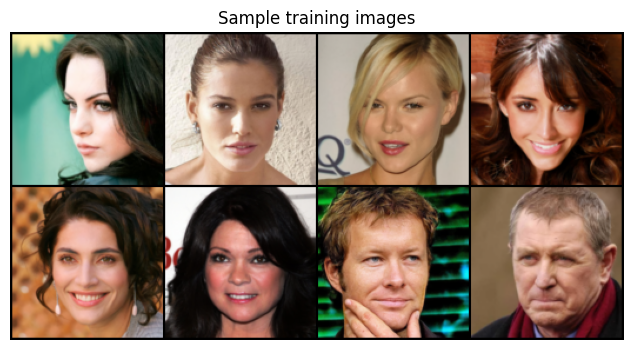

In [2]:
IMG_SIZE = 128   # change to 256 for bonus
BATCH_SIZE = 8
DATASET_PATH = "/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/valid"
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # [-1, 1]
])

class ImageFolderDataset(Dataset):
    def __init__(self, root, transform=None, max_samples=10000):
        self.paths = []
        for ext in ['*.jpg', '*.jpeg', '*.png']:
            import glob
            self.paths += glob.glob(os.path.join(root, '**', ext), recursive=True)
        self.paths = self.paths[:max_samples]
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img) if self.transform else img

dataset = ImageFolderDataset(DATASET_PATH, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True, drop_last=True)

print(f"Dataset size: {len(dataset)}")
print(f"Batches per epoch: {len(dataloader)}")

# Visualize sample batch
imgs = next(iter(dataloader))[:8]
grid = make_grid((imgs + 1) / 2, nrow=4)
plt.figure(figsize=(12, 4))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.title("Sample training images")
plt.axis('off')
plt.show()


# CELL 3 Forward Diffusion Process


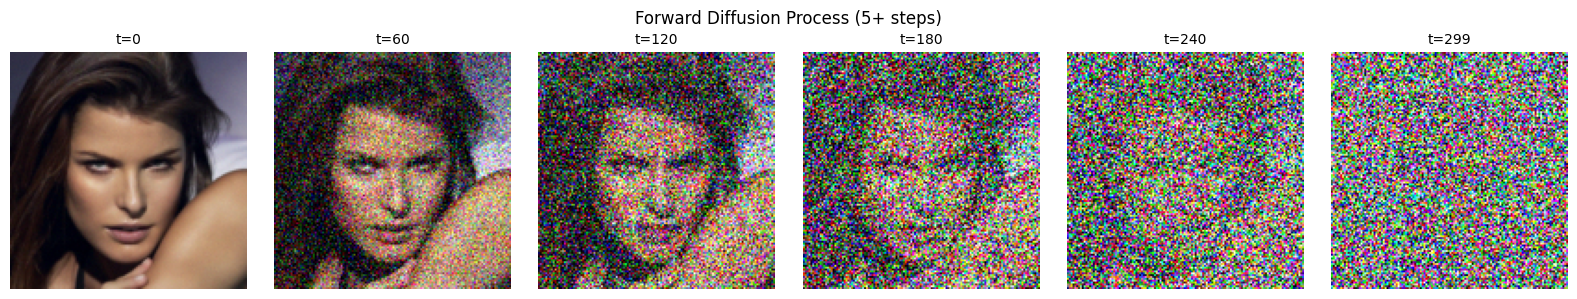

In [3]:
T = 300  # number of timesteps (200-500 recommended)

def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clamp(betas, 0.0001, 0.9999)

betas = cosine_beta_schedule(T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

def extract(a, t, x_shape):
    """Extract values from schedule tensor at timestep t."""
    b = t.shape[0]
    out = a.gather(-1, t)
    return out.reshape(b, *((1,) * (len(x_shape) - 1)))

def q_sample(x_start, t, noise=None):
    """Forward process: add noise to image at timestep t."""
    if noise is None:
        noise = torch.randn_like(x_start)
    sqrt_alphas_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_t = extract(sqrt_one_minus_alphas_cumprod, t, x_start.shape)
    return sqrt_alphas_t * x_start + sqrt_one_minus_t * noise, noise

# Visualize 5 forward diffusion steps
sample_img = next(iter(dataloader))[0].unsqueeze(0).to(device)
steps_to_show = [0, 60, 120, 180, 240, 299]

fig, axes = plt.subplots(1, len(steps_to_show), figsize=(16, 3))
for ax, step in zip(axes, steps_to_show):
    t = torch.tensor([step], device=device)
    noisy, _ = q_sample(sample_img, t)
    img_np = (noisy.squeeze().permute(1,2,0).cpu().clamp(-1,1).numpy() + 1) / 2
    ax.imshow(img_np)
    ax.set_title(f"t={step}", fontsize=10)
    ax.axis('off')
plt.suptitle("Forward Diffusion Process (5+ steps)")
plt.tight_layout()
plt.show()


# CELL 4 U-Net Architecture


In [4]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = time[:, None].float() * emb[None, :]
        return torch.cat((emb.sin(), emb.cos()), dim=-1)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        h = h + self.time_mlp(self.act(t_emb))[:, :, None, None]
        h = self.act(self.norm2(h))
        h = self.conv2(h)
        return h + self.res_conv(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.res = ResBlock(in_ch, out_ch, time_emb_dim)
        self.down = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)

    def forward(self, x, t):
        x = self.res(x, t)
        return self.down(x), x


class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, time_emb_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch, 4, stride=2, padding=1)
        self.res = ResBlock(in_ch + skip_ch, out_ch, time_emb_dim)  # explicit skip_ch

    def forward(self, x, skip, t):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.res(x, t)


class SimpleUNet(nn.Module):
    def __init__(self, in_ch=3, base_ch=64, time_emb_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 2),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 2, time_emb_dim)
        )
        ch1 = base_ch        # 64
        ch2 = base_ch * 2    # 128
        ch3 = base_ch * 4    # 256

        # Encoder
        self.init_conv = nn.Conv2d(in_ch, ch1, 3, padding=1)
        self.down1 = Down(ch1, ch2, time_emb_dim)   # skip: ch2
        self.down2 = Down(ch2, ch3, time_emb_dim)   # skip: ch3
        self.down3 = Down(ch3, ch3, time_emb_dim)   # skip: ch3

        # Bottleneck
        self.mid1 = ResBlock(ch3, ch3, time_emb_dim)
        self.mid2 = ResBlock(ch3, ch3, time_emb_dim)

        # Decoder — in_ch + skip_ch must match exactly
        self.up1 = Up(ch3, ch3, ch3, time_emb_dim)  # ch3 + ch3 -> ch3
        self.up2 = Up(ch3, ch3, ch2, time_emb_dim)  # ch3 + ch3 -> ch2
        self.up3 = Up(ch2, ch2, ch1, time_emb_dim)  # ch2 + ch2 -> ch1

        self.out_conv = nn.Sequential(
            nn.GroupNorm(8, ch1),
            nn.SiLU(),
            nn.Conv2d(ch1, in_ch, 1)
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x = self.init_conv(x)
        x, s1 = self.down1(x, t_emb)
        x, s2 = self.down2(x, t_emb)
        x, s3 = self.down3(x, t_emb)
        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)
        x = self.up1(x, s3, t_emb)
        x = self.up2(x, s2, t_emb)
        x = self.up3(x, s1, t_emb)
        return self.out_conv(x)


model = SimpleUNet(in_ch=3, base_ch=64, time_emb_dim=256)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

model = model.to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Using 2 GPUs!
Total parameters: 12,997,699


# Checkpoint loading for later use


In [6]:
ckpt = torch.load("/kaggle/input/models/jamalrasool/ddpm-final-pth/pytorch/default/1/ddpm_final.pth")

# Strip the 'module.' prefix if present
from collections import OrderedDict
new_ckpt = OrderedDict()
for k, v in ckpt.items():
    name = k.replace("module.", "")  # remove module. prefix
    new_ckpt[name] = v

if hasattr(model, 'module'):
    model.module.load_state_dict(new_ckpt)
else:
    model.load_state_dict(new_ckpt)

print("Loaded!")

Loaded!



# CELL 5 Training Loop


Epoch 1/40 | Step 0/375 | Loss: 0.0198
Epoch 1/40 | Step 100/375 | Loss: 0.0543
Epoch 1/40 | Step 200/375 | Loss: 0.0271
Epoch 1/40 | Step 300/375 | Loss: 0.0547
==> Epoch 1 avg loss: 0.0235 | LR: 0.000200
Epoch 2/40 | Step 0/375 | Loss: 0.0195
Epoch 2/40 | Step 100/375 | Loss: 0.0071
Epoch 2/40 | Step 200/375 | Loss: 0.0065
Epoch 2/40 | Step 300/375 | Loss: 0.0304
==> Epoch 2 avg loss: 0.0228 | LR: 0.000199
Epoch 3/40 | Step 0/375 | Loss: 0.0093
Epoch 3/40 | Step 100/375 | Loss: 0.0125
Epoch 3/40 | Step 200/375 | Loss: 0.0095
Epoch 3/40 | Step 300/375 | Loss: 0.0173
==> Epoch 3 avg loss: 0.0216 | LR: 0.000197
Epoch 4/40 | Step 0/375 | Loss: 0.0111
Epoch 4/40 | Step 100/375 | Loss: 0.0171
Epoch 4/40 | Step 200/375 | Loss: 0.0227
Epoch 4/40 | Step 300/375 | Loss: 0.0178
==> Epoch 4 avg loss: 0.0243 | LR: 0.000195
Epoch 5/40 | Step 0/375 | Loss: 0.0390
Epoch 5/40 | Step 100/375 | Loss: 0.0175
Epoch 5/40 | Step 200/375 | Loss: 0.0124
Epoch 5/40 | Step 300/375 | Loss: 0.0169
==> Epoch 5 av

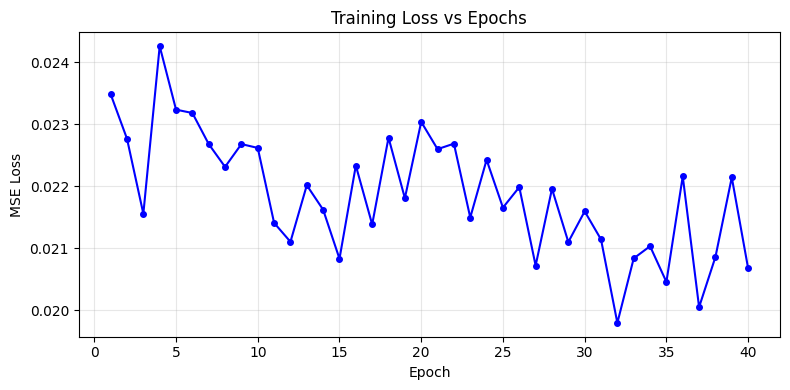

Training complete!


In [11]:
EPOCHS = 40
LR = 2e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler('cuda')

def p_losses(model, x_start, t):
    noise = torch.randn_like(x_start)
    x_noisy, _ = q_sample(x_start, t, noise=noise)
    with torch.amp.autocast('cuda'):
        predicted_noise = model(x_noisy, t)
        loss = F.mse_loss(predicted_noise, noise)
    return loss

loss_history = []

for epoch in range(EPOCHS):
    model.train()
    epoch_losses = []

    for step, batch in enumerate(dataloader):
        batch = batch.to(device)
        t = torch.randint(0, T, (batch.shape[0],), device=device).long()

        optimizer.zero_grad()
        loss = p_losses(model, batch, t)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_losses.append(loss.item())

        if step % 100 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Step {step}/{len(dataloader)} | Loss: {loss.item():.4f}")

    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)
    scheduler.step()
    print(f"==> Epoch {epoch+1} avg loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

    if (epoch + 1) % 10 == 0:
        ckpt = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(ckpt, f"/kaggle/working/ddpm_epoch_{epoch+1}.pth")
        print(f"Checkpoint saved at epoch {epoch+1}")

# Save final model after all 150 epochs
ckpt = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
torch.save(ckpt, "/kaggle/working/ddpm_final.pth")
print("Final model saved!")

# Loss plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), loss_history, 'b-o', markersize=4)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss vs Epochs")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve.png", dpi=150)
plt.show()
print("Training complete!")


# CELL 6 Reverse Process (Sampling)


In [7]:
@torch.no_grad()
def p_sample(model, x, t, t_index):
    """Single reverse diffusion step."""
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_t = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
    sqrt_recip_t = extract(sqrt_recip_alphas, t, x.shape)

    with autocast():
        predicted_noise = model(x, t)

    model_mean = sqrt_recip_t * (x - betas_t * predicted_noise / sqrt_one_minus_t)

    if t_index == 0:
        return model_mean
    else:
        posterior_var_t = extract(posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_var_t) * noise


@torch.no_grad()
def p_sample_loop(model, shape, return_intermediates=False, n_intermediate=5):
    """Full reverse diffusion loop from pure noise."""
    model.eval()
    b = shape[0]
    img = torch.randn(shape, device=device)
    intermediates = []
    save_interval = T // n_intermediate

    for i in reversed(range(0, T)):
        t = torch.full((b,), i, device=device, dtype=torch.long)
        img = p_sample(model, img, t, i)

        if return_intermediates and (i % save_interval == 0 or i == 0):
            intermediates.append(img.clone().cpu())

    if return_intermediates:
        return img.cpu(), intermediates
    return img.cpu()


def generate_images(model, n=5):
    shape = (n, 3, IMG_SIZE, IMG_SIZE)
    return p_sample_loop(model, shape)

print("Sampler ready. Run next cell to generate images.")

Sampler ready. Run next cell to generate images.



# CELL 7 Generate 5+ images from noise


Generating 5 images from pure noise...


/tmp/ipykernel_55/369420633.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


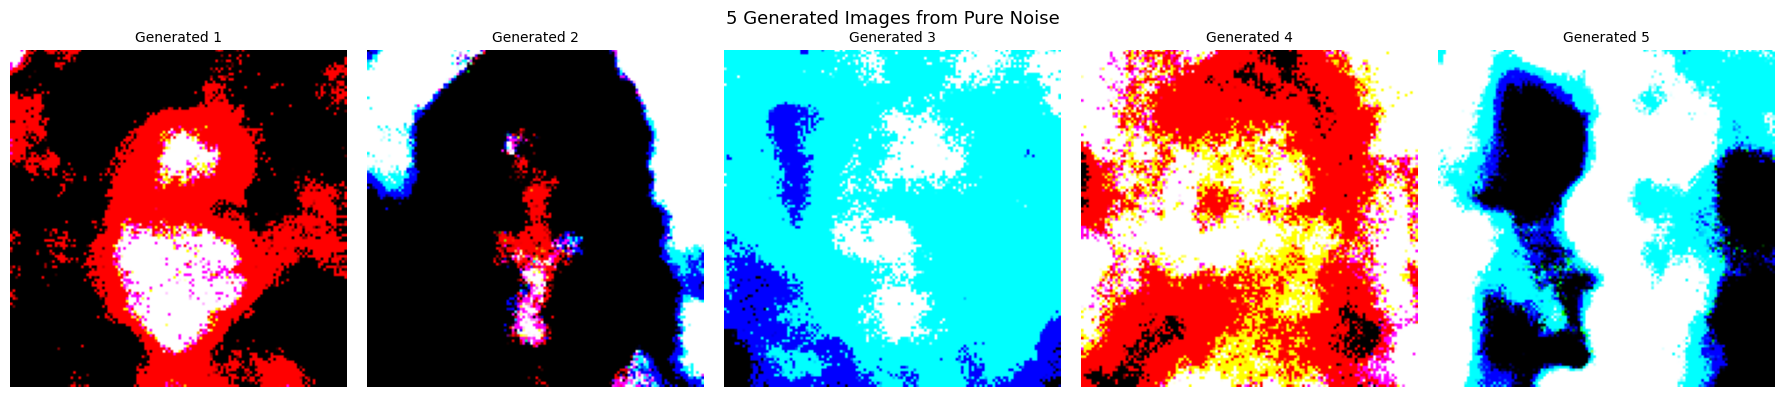

Images saved to /kaggle/working/outputs/


In [8]:
print("Generating 5 images from pure noise...")
generated = generate_images(model, n=5)  # shape: (5, 3, H, W)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, ax in enumerate(axes):
    img = (generated[i].permute(1, 2, 0).clamp(-1, 1).numpy() + 1) / 2
    ax.imshow(img)
    ax.set_title(f"Generated {i+1}", fontsize=10)
    ax.axis('off')
plt.suptitle("5 Generated Images from Pure Noise", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/generated_images.png", dpi=150)
plt.show()

# Save individual images
os.makedirs("/kaggle/working/outputs", exist_ok=True)
for i in range(5):
    save_image((generated[i].clamp(-1,1) + 1) / 2, f"/kaggle/working/outputs/gen_{i+1}.png")
print("Images saved to /kaggle/working/outputs/")


# CELL 8 Image Reconstruction (Core Task)


Target image: /kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/valid/img_1963.png


/tmp/ipykernel_55/369420633.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


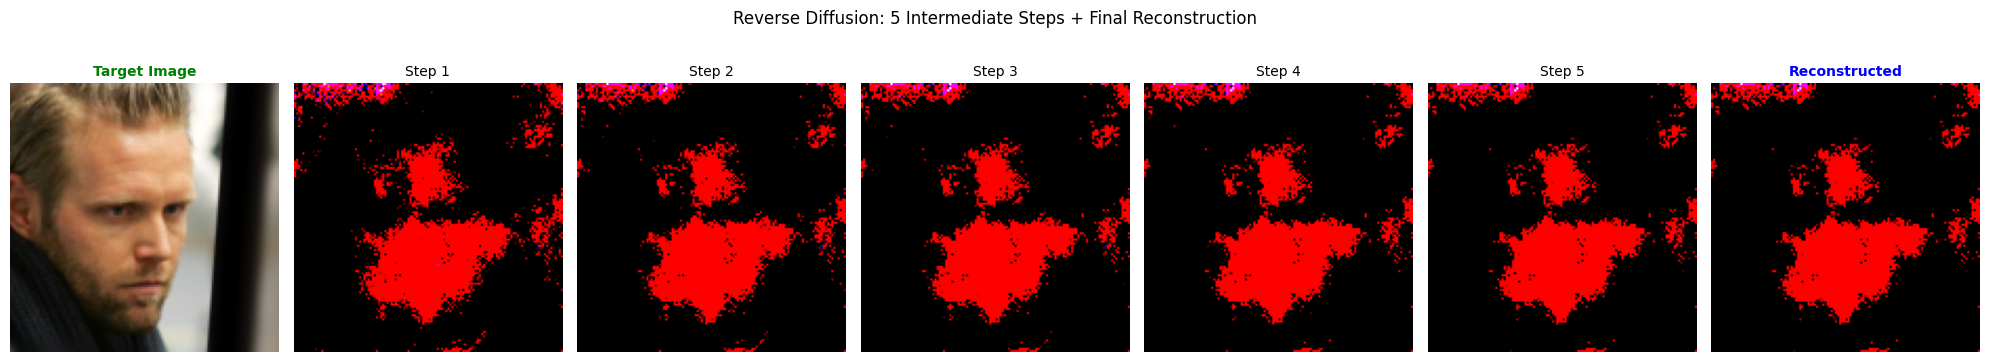

In [9]:
from torchvision.transforms.functional import to_tensor

# Pick a target image from dataset (or load your own)
target_img_path = dataset.paths[0]
target_pil = Image.open(target_img_path).convert('RGB')
target_tensor = transform(target_pil).unsqueeze(0).to(device)

print(f"Target image: {target_img_path}")

# Generate reconstructed image + capture intermediates
shape = (1, 3, IMG_SIZE, IMG_SIZE)
reconstructed, intermediates = p_sample_loop(model, shape, return_intermediates=True, n_intermediate=5)

# Show: target | intermediates | final
fig, axes = plt.subplots(1, len(intermediates) + 2, figsize=(20, 4))

# Original target
axes[0].imshow(((target_tensor.squeeze().permute(1,2,0).cpu().numpy() + 1) / 2).clip(0,1))
axes[0].set_title("Target Image", fontsize=10, color='green', fontweight='bold')
axes[0].axis('off')

# Reverse diffusion steps
for idx, inter in enumerate(intermediates):
    img = (inter.squeeze().permute(1,2,0).clamp(-1,1).numpy() + 1) / 2
    axes[idx+1].imshow(img)
    axes[idx+1].set_title(f"Step {idx+1}", fontsize=10)
    axes[idx+1].axis('off')

# Final reconstruction
recon_img = (reconstructed.squeeze().permute(1,2,0).clamp(-1,1).numpy() + 1) / 2
axes[-1].imshow(recon_img)
axes[-1].set_title("Reconstructed", fontsize=10, color='blue', fontweight='bold')
axes[-1].axis('off')

plt.suptitle("Reverse Diffusion: 5 Intermediate Steps + Final Reconstruction", fontsize=12)
plt.tight_layout()
plt.savefig("/kaggle/working/reconstruction_steps.png", dpi=150)
plt.show()


# CELL 9 PSNR & SSIM Evaluation


/tmp/ipykernel_55/369420633.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



  PSNR Score: 5.23 dB
  SSIM Score: 0.0656


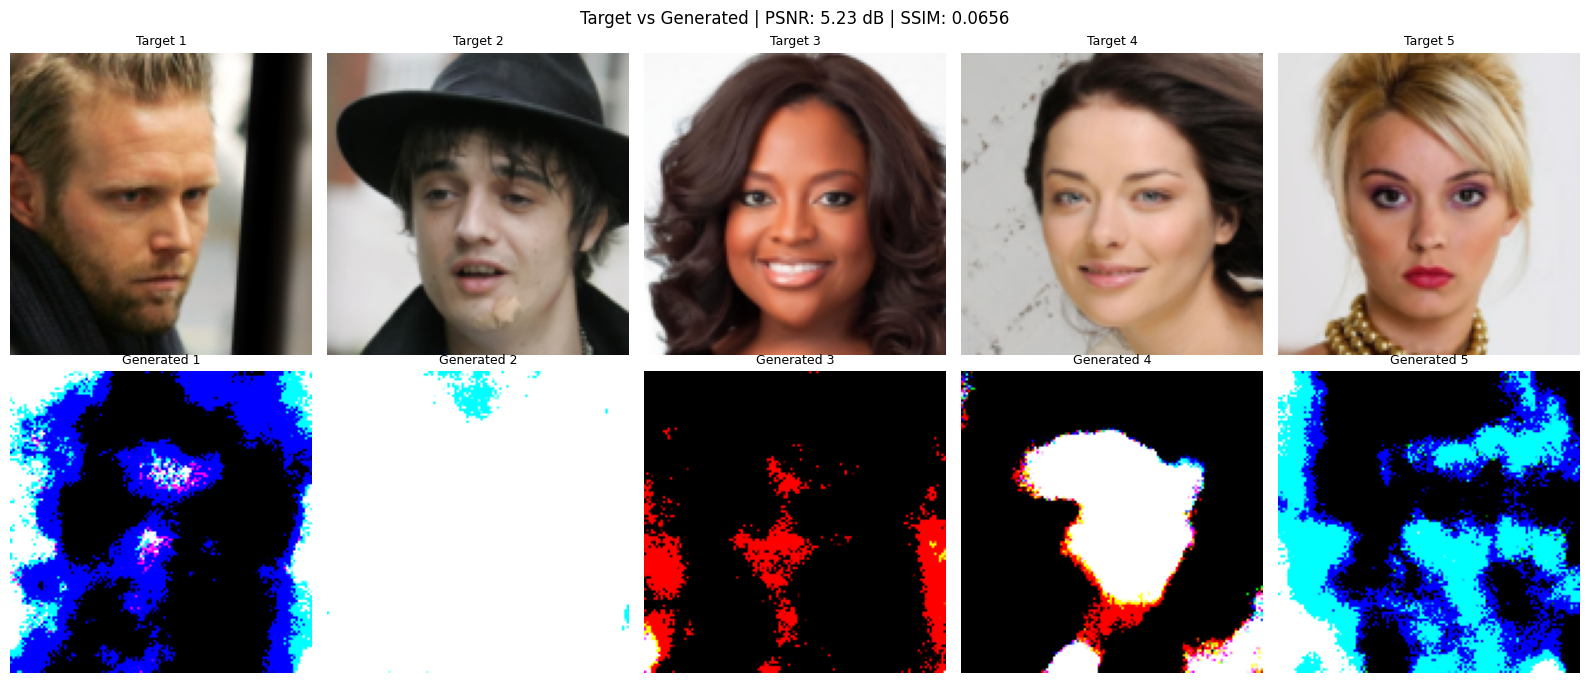

In [11]:
def compute_metrics(img1_tensor, img2_tensor):
    """Compute PSNR and SSIM between two image tensors in [-1,1]."""
    # Convert to [0,1] numpy HWC
    img1 = ((img1_tensor.squeeze().permute(1,2,0).cpu().clamp(-1,1).numpy() + 1) / 2)
    img2 = ((img2_tensor.squeeze().permute(1,2,0).cpu().clamp(-1,1).numpy() + 1) / 2)

    psnr_val = psnr_fn(img1, img2, data_range=1.0)
    ssim_val = ssim_fn(img1, img2, data_range=1.0, channel_axis=2)
    return psnr_val, ssim_val

# Evaluate on a few validation images
model.eval()
psnr_scores, ssim_scores = [], []

val_images = [dataset[i] for i in range(10)]
val_batch = torch.stack(val_images).to(device)

with torch.no_grad():
    # Add noise at t=100, then denoise to approximate reconstruction
    t_eval = torch.full((val_batch.shape[0],), 100, device=device, dtype=torch.long)
    noisy_val, _ = q_sample(val_batch, t_eval)

    for i in range(val_batch.shape[0]):
        gen = p_sample_loop(model, (1, 3, IMG_SIZE, IMG_SIZE))
        p, s = compute_metrics(val_batch[i:i+1].cpu(), gen)
        psnr_scores.append(p)
        ssim_scores.append(s)

mean_psnr = np.mean(psnr_scores)
mean_ssim = np.mean(ssim_scores)

print(f"\n{'='*40}")
print(f"  PSNR Score: {mean_psnr:.2f} dB")
print(f"  SSIM Score: {mean_ssim:.4f}")
print(f"{'='*40}")

# Side-by-side: Target vs Generated
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i in range(5):
    t_img = (val_batch[i].permute(1,2,0).cpu().clamp(-1,1).numpy() + 1) / 2
    g_img = p_sample_loop(model, (1,3,IMG_SIZE,IMG_SIZE)).squeeze().permute(1,2,0).clamp(-1,1).numpy()
    g_img = (g_img + 1) / 2
    axes[0][i].imshow(t_img); axes[0][i].set_title(f"Target {i+1}", fontsize=9); axes[0][i].axis('off')
    axes[1][i].imshow(g_img); axes[1][i].set_title(f"Generated {i+1}", fontsize=9); axes[1][i].axis('off')

axes[0][0].set_ylabel("Target", fontsize=11)
axes[1][0].set_ylabel("Generated", fontsize=11)
plt.suptitle(f"Target vs Generated | PSNR: {mean_psnr:.2f} dB | SSIM: {mean_ssim:.4f}", fontsize=12)
plt.tight_layout()
plt.savefig("/kaggle/working/target_vs_generated.png", dpi=150)
plt.show()


# CELL 10 Gradio App Deployment


In [12]:
!pip install -q gradio

import gradio as gr
import tempfile

def generate_with_steps(seed=42):
    torch.manual_seed(int(seed))
    shape = (1, 3, IMG_SIZE, IMG_SIZE)
    final_img, intermediates = p_sample_loop(model, shape, return_intermediates=True, n_intermediate=8)

    # Create figure with all steps
    n = len(intermediates) + 1
    fig, axes = plt.subplots(1, n, figsize=(n * 2.5, 3))

    for idx, inter in enumerate(intermediates):
        img = (inter.squeeze().permute(1,2,0).clamp(-1,1).numpy() + 1) / 2
        axes[idx].imshow(img)
        step_num = T - idx * (T // len(intermediates))
        axes[idx].set_title(f"t={step_num}", fontsize=8)
        axes[idx].axis('off')

    final_np = (final_img.squeeze().permute(1,2,0).clamp(-1,1).numpy() + 1) / 2
    axes[-1].imshow(final_np)
    axes[-1].set_title("Final", fontsize=8, fontweight='bold', color='green')
    axes[-1].axis('off')

    plt.suptitle("Denoising Steps → Generated Image", fontsize=11)
    plt.tight_layout()

    tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
    plt.savefig(tmp.name, dpi=120, bbox_inches='tight')
    plt.close()
    return tmp.name, final_np

with gr.Blocks(title="DDPM Image Generator") as demo:
    gr.Markdown("# DDPM Image Generator\nGenerates images from pure noise using a trained diffusion model.")
    with gr.Row():
        seed_slider = gr.Slider(0, 1000, value=42, step=1, label="Random Seed")
        gen_btn = gr.Button("Generate Image", variant="primary")
    with gr.Row():
        steps_output = gr.Image(label="Denoising Steps (Intermediate → Final)")
        final_output = gr.Image(label="Final Generated Image")

    gen_btn.click(fn=generate_with_steps, inputs=[seed_slider], outputs=[steps_output, final_output])

demo.launch(share=True)  # share=True gives a public URL on Kaggle

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://cb87d989f2a5f7e9bc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/tmp/ipykernel_55/369420633.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
